In [41]:
# importing the libraries...
from imports import *
from datasets import *

# importing the dataset...
# Reading the dataset cashless_claim_prediction.csv...
raw_data = pd.read_csv(cashless_claim_prediction)
# checking the shape of the dataset...
print('The shape of the dataset is :',raw_data.shape)
raw_data.head()


The shape of the dataset is : (5000, 41)


,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,NaN,0.0,2,...,2201.0,0,1000,0,59420,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636,38276,23423,22119,96.0,31538


In [42]:
df = raw_data.copy()

display(df.head(3))
print('------ Info ---------')
display(df.info())

print('----Missing Values -----')
missing = df.isna().mean().sort_values(ascending = False)
print(missing)
display((missing.head(15)*100).round(2).to_frame('missing_%'))

print('======Numeric Summary (few Columns) ======')
num_cols=df.select_dtypes(include=[np.number]).columns
if len(num_cols)>0:
    display(df[num_cols].describe().T.head(12))


,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351


------ Info ---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   claim_id                           5000 non-null   object 
 1   patient_id                         5000 non-null   object 
 2   hospital_id                        5000 non-null   object 
 3   claim_submitted_date               5000 non-null   object 
 4   age                                5000 non-null   int64  
 5   gender                             5000 non-null   object 
 6   city_tier                          4951 non-null   float64
 7   bmi                                4779 non-null   float64
 8   smoker_flag                        4876 non-null   float64
 9   comorbidity_score                  5000 non-null   int64  
 10  prior_claim_count_2yr              5000 non-null   int64  
 11  prior_claim_amount_2yr            

None

----Missing Values -----
bmi                                  0.0442
document_quality_score               0.0348
smoker_flag                          0.0248
hospital_billing_index               0.0198
room_rent_limit_per_day              0.0148
city_tier                            0.0098
age                                  0.0000
claim_id                             0.0000
patient_id                           0.0000
gender                               0.0000
hospital_id                          0.0000
claim_submitted_date                 0.0000
comorbidity_score                    0.0000
treatment_type                       0.0000
prior_claim_count_2yr                0.0000
prior_claim_amount_2yr               0.0000
admission_type                       0.0000
procedure_complexity_score           0.0000
icu_days                             0.0000
length_of_stay_days                  0.0000
pre_existing_disease_flag            0.0000
hospital_type                        0.0000
diagnos

,missing_%
bmi,4.42
document_quality_score,3.48
smoker_flag,2.48
hospital_billing_index,1.98
room_rent_limit_per_day,1.48
city_tier,0.98
age,0.00
claim_id,0.00
patient_id,0.00
gender,0.00


======Numeric Summary (few Columns) ======


,count,mean,std,min,25%,50%,75%,max
age,5000.0,41.820000,19.659301,0.0,30.0,43.0,54.00,150.0
city_tier,4951.0,1.899414,0.808029,1.0,1.0,2.0,3.00,3.0
bmi,4779.0,25.078301,5.374184,-3.5,22.1,25.0,27.90,80.0
smoker_flag,4876.0,0.174733,0.379778,0.0,0.0,0.0,0.00,1.0
comorbidity_score,5000.0,1.682200,1.362341,0.0,1.0,1.0,2.00,8.0
prior_claim_count_2yr,5000.0,0.668800,0.803266,0.0,0.0,0.0,1.00,5.0
prior_claim_amount_2yr,5000.0,15437.033400,25447.022739,0.0,0.0,0.0,22149.25,336714.0
severity_level,5000.0,3.207200,1.237972,1.0,2.0,3.0,4.00,5.0
procedure_count,5000.0,1.464000,1.296395,0.0,0.0,1.0,2.00,8.0
procedure_complexity_score,5000.0,5.004020,2.068840,0.0,3.5,4.9,6.50,10.0


In [43]:
df.describe(include=object).T

,count,unique,top,freq
claim_id,5000,4904,CLM00002660,2
patient_id,5000,1947,PAT001099,9
hospital_id,5000,259,HSP0128,32
claim_submitted_date,5000,1083,2024-02-03,13
gender,5000,6,Male,2631
admission_type,5000,2,Planned,3085
treatment_type,5000,4,Non-Surgery,2011
diagnosis_category,5000,11,Orthopedic,869
hospital_type,5000,3,Corporate,2820
hospital_tier,5000,3,B,2105


In [44]:
# Data Quality Checklist ...
# Missing values 
# Exact Duplicates 
#Invalid Entries

# Duplicates check ...
print('------ Duplicate Rows -------')
display((df.duplicated(subset=None, keep='first')).sum())
# Invalid checks (only if columns exists)
checks = {}

if 'age' in df.columns:
    checks['age_invalid(>100 or <0)'] = int(((df['age'] > 100) | (df['age'] < 0)).sum())
if 'bmi' in df.columns:
    checks['bmi_invalid(>60 or <10)'] = int(((df['bmi'] > 60) | (df['bmi'] < 10)).sum())
if 'copay_percent' in df.columns:
    checks['copay_percent_invalid(>100 or <0)']= int(((df['copay_percent']>100) | (df['copay_percent']< 0)).sum())
if 'claimed_amount' in df.columns:
    checks['claim_amount_invalid(<=0)'] = int ((df['claimed_amount'] <= 0).sum())
    
print('------ Invalid Entries -------')
for k,v in checks.items():
    print(f'{k} : {v}')


------ Duplicate Rows -------


np.int64(96)

------ Invalid Entries -------
age_invalid(>100 or <0) : 41
bmi_invalid(>60 or <10) : 26
copay_percent_invalid(>100 or <0) : 6
claim_amount_invalid(<=0) : 20


In [52]:
def standardize_gender(x):

    if pd.isna(x):

        return np.nan

    s = str(x).strip().lower()

    if s in {'m', 'male'}:

        return 'Male'

    if s in {'f', 'female'}:

        return 'Female'

    if s in {'other', 'o'}:

        return 'Other'

    # common noisy values

    if s in {'unknown', 'na', 'n/a', ''}:

        return 'Unknown'

    # fallback

    return 'Other'

 

 

def clean_claims_data(df_in: pd.DataFrame) -> pd.DataFrame:

    df = df_in.copy()

 

    # 1) Drop exact duplicates

    df = df.drop_duplicates().reset_index(drop=True)
    # 2) Parse date + create date features

    if 'claim_submitted_date' in df.columns:

        df['claim_submitted_date'] = pd.to_datetime(df['claim_submitted_date'], errors='coerce')

        df['claim_month'] = df['claim_submitted_date'].dt.month

        df['claim_quarter'] = df['claim_submitted_date'].dt.quarter

        df['claim_dayofweek'] = df['claim_submitted_date'].dt.dayofweek

 

    # 3) Standardize gender

    if 'gender' in df.columns:

        df['gender'] = df['gender'].apply(standardize_gender)

 

    # 4) Fix invalid numeric values (clip or set to NaN)

    if 'age' in df.columns:

        df['age'] = pd.to_numeric(df['age'], errors='coerce')

        # clip to a realistic range for classroom (0–90)

        df['age'] = df['age'].clip(lower=0, upper=90)

 

    if 'bmi' in df.columns:

        df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

        df.loc[(df['bmi'] < 10) | (df['bmi'] > 60), 'bmi'] = np.nan

 

    if 'copay_percent' in df.columns:

        df['copay_percent'] = pd.to_numeric(df['copay_percent'], errors='coerce')

        df['copay_percent'] = df['copay_percent'].clip(lower=0, upper=100)




    # Claimed/approved amounts must be valid

    for col in ['claimed_amount', 'approved_amount', 'sum_insured', 'remaining_sum_insured',

                'room_charges', 'doctor_fees', 'medicine_charges', 'deductible_amount',

                'room_rent_limit_per_day']:

        if col in df.columns:

            df[col] = pd.to_numeric(df[col], errors='coerce')

 

    if 'claimed_amount' in df.columns:

        df.loc[df['claimed_amount'] <= 0, 'claimed_amount'] = np.nan

 

    if 'approved_amount' in df.columns:

        df.loc[df['approved_amount'] < 0, 'approved_amount'] = 0

 

    # Ensure remaining_sum_insured <= sum_insured

    if {'remaining_sum_insured', 'sum_insured'}.issubset(df.columns):

        df['remaining_sum_insured'] = df[['remaining_sum_insured', 'sum_insured']].min(axis=1)

 

    # Ensure approved_amount is not above claimed_amount / remaining_sum_insured

    if {'approved_amount', 'claimed_amount'}.issubset(df.columns):

        df['approved_amount'] = np.where(df['approved_amount'] > df['claimed_amount'], df['claimed_amount'], df['approved_amount'])

 

    if {'approved_amount', 'remaining_sum_insured'}.issubset(df.columns):

        df['approved_amount'] = np.where(df['approved_amount'] > df['remaining_sum_insured'], df['remaining_sum_insured'], df['approved_amount'])




    # Non-negative components

    for col in ['room_charges', 'doctor_fees', 'medicine_charges']:

        if col in df.columns:

            df.loc[df[col] < 0, col] = 0

 

    # 5) Drop rows where critical fields are missing

    critical = [c for c in ['claimed_amount', 'approved_amount'] if c in df.columns]

    df = df.dropna(subset=critical).reset_index(drop=True)

 

    # 6) Impute missing values

    # - numeric: median

    # - categorical: 'Unknown'

    num_cols = df.select_dtypes(include=[np.number]).columns

    cat_cols = df.select_dtypes(include=['object']).columns

 

    for c in num_cols:

        if df[c].isna().any():

            df[c] = df[c].fillna(df[c].median())

 

    for c in cat_cols:

        if df[c].isna().any():

            df[c] = df[c].fillna('Unknown')

 

    return df

 

 

clean_df = clean_claims_data(df)

print("Before cleaning:", df.shape)

print("After cleaning:", clean_df.shape)

clean_df.head()










Before cleaning: (4884, 44)
After cleaning: (4884, 44)


,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount,claim_month,claim_quarter,claim_dayofweek
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,25.0,0.0,1,...,0,50974.0,22119,7975,10083,100.0,20662.0,8,3,5
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,0,57113.0,22148,13163,11712,74.0,35592.0,4,2,3
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,0,51824.0,30179,8293,10292,61.0,48351.0,7,3,1
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,25.0,0.0,2,...,0,59420.0,20321,8625,18688,64.0,35995.0,6,2,2
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,0,105636.0,38276,23423,22119,96.0,31538.0,1,1,6


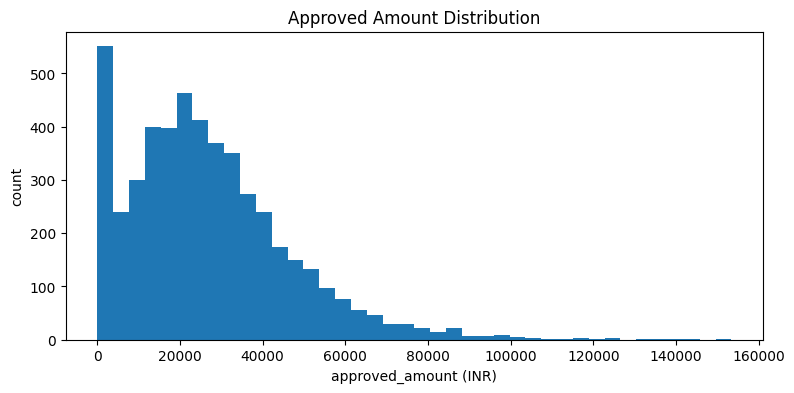

Auto-observations:
- Skewness: 1.15 (right-skew if > 0)
- Outlier share (IQR rule): 2.7%
- Median approved amount: 23,948 INR


In [46]:
#Distribution of approved amount ...
df = clean_df.copy()
plt.figure(figsize=(9,4))
plt.hist(df['approved_amount'], bins=40)
plt.title('Approved Amount Distribution')
plt.xlabel('approved_amount (INR)')
plt.ylabel('count')
plt.show()
# Auto - Observation ...
skew = df['approved_amount'].skew()
q1, q3 = df['approved_amount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = ((df['approved_amount'] < (q1 - 1.5*iqr)) | (df['approved_amount'] > (q3 + 1.5*iqr))).mean()

print("Auto-observations:")
print(f"- Skewness: {skew:.2f} (right-skew if > 0)")
print(f"- Outlier share (IQR rule): {outliers*100:.1f}%")
print(f"- Median approved amount: {df['approved_amount'].median():,.0f} INR")

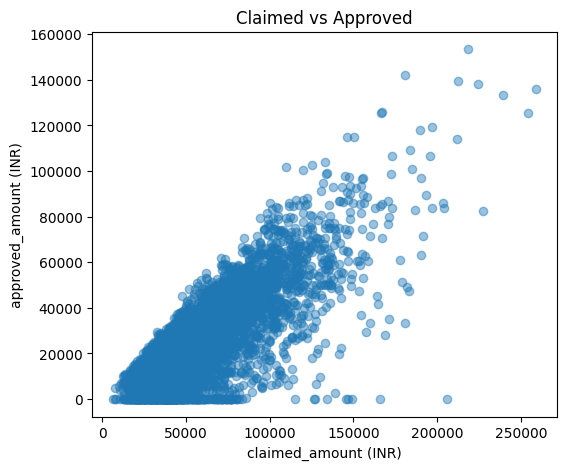

Auto-observations:
- Correlation(claimed, approved): 0.77
- % cases where approved < claimed (likely caps/denials/copay): 100.0%


In [47]:
# Claimed amount vs Approved amount
if {'claimed_amount', 'approved_amount'}.issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['claimed_amount'], df['approved_amount'], alpha=0.45)
    plt.title('Claimed vs Approved')
    plt.xlabel('claimed_amount (INR)')
    plt.ylabel('approved_amount (INR)')
    plt.show()

corr = df[['claimed_amount', 'approved_amount']].corr().iloc[0,1]
approx_cap = (df['approved_amount'] < df['claimed_amount']).mean()
print("Auto-observations:")
print(f"- Correlation(claimed, approved): {corr:.2f}")
print(f"- % cases where approved < claimed (likely caps/denials/copay): {approx_cap*100:.1f}%")

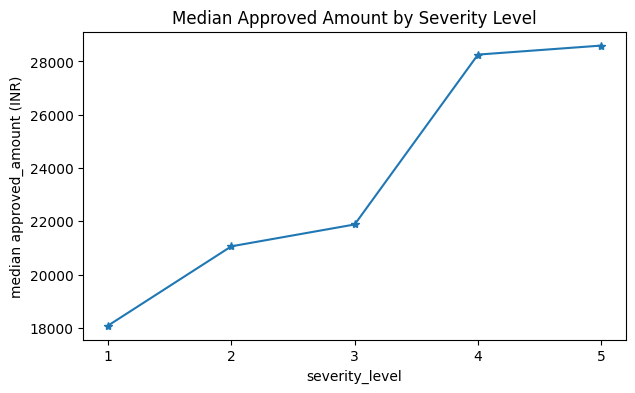

Auto-observations:
- Median approval by severity:
  severity 1: 18,087 INR
  severity 2: 21,060 INR
  severity 3: 21,879 INR
  severity 4: 28,250 INR
  severity 5: 28,588 INR


In [48]:
# Severity leval vs Approved amount...
if 'severity_level' in df.columns:
    grp = df.groupby('severity_level')['approved_amount'].median().sort_index()

    plt.figure(figsize=(7,4))
    plt.plot(grp.index, grp.values, marker='*')
    plt.title('Median Approved Amount by Severity Level')
    plt.xlabel('severity_level')
    plt.ylabel('median approved_amount (INR)')
    plt.xticks(grp.index)
    plt.show()

    print("Auto-observations:")
    print("- Median approval by severity:")
    for k, v in grp.items():
        print(f"  severity {k}: {v:,.0f} INR")

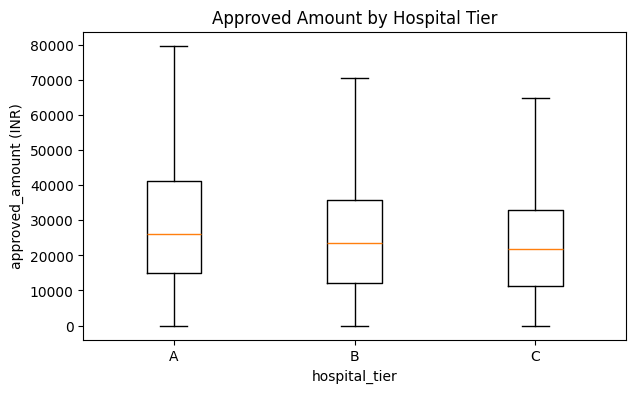

Auto-observations:


,median_approved_amount
hospital_tier,
A,26188.0
B,23391.5
C,21764.0


In [49]:
# Hospital Tier vs Approved amount...
if 'hospital_tier' in df.columns:
    # Sort tiers so A, B, C appear in alphabetical order
    tiers = sorted(df['hospital_tier'].dropna().unique())
    data = [df[df['hospital_tier'] == t]['approved_amount'] for t in tiers]

    plt.figure(figsize=(7,4))
    plt.boxplot(data, labels=tiers, showfliers=False)
    plt.title('Approved Amount by Hospital Tier')
    plt.xlabel('hospital_tier')
    plt.ylabel('approved_amount (INR)')
    plt.show()

    med = df.groupby('hospital_tier')['approved_amount'].median().sort_index()
    print("Auto-observations:")
    display(med.to_frame('median_approved_amount')) # to_frame is the method for converting a series into dataframe...

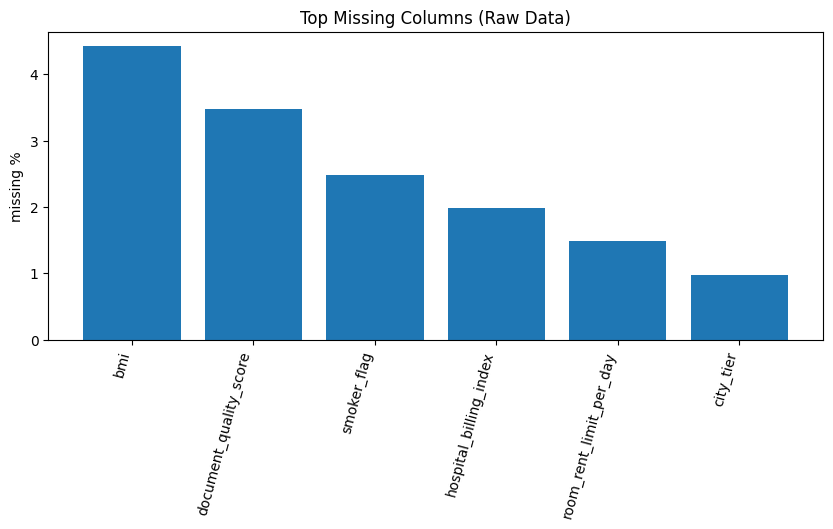

Auto-observation:
- These columns will need imputation or careful handling before modeling.


In [50]:
# missing values (before cleaning)
miss = raw_data.isna().mean().sort_values(ascending=False) # enough this line next lines are beautifician...
miss = miss[miss > 0]

plt.figure(figsize=(10,4))
plt.bar(miss.index[:15], (miss.values[:15] * 100))
plt.title('Top Missing Columns (Raw Data)')
plt.ylabel('missing %')
plt.xticks(rotation=75, ha='right')
plt.show()

print("Auto-observation:")
print("- These columns will need imputation or careful handling before modeling.")

In [53]:
fe_df = clean_df.copy()

 

def safe_divide(a, b):

    return np.where(b == 0, 0, a / b)

 

# Ratios

for num, name in [('room_charges','room_ratio'), ('medicine_charges','medicine_ratio'), ('doctor_fees','doctor_ratio')]:

    if {num, 'claimed_amount'}.issubset(fe_df.columns):

        fe_df[name] = safe_divide(fe_df[num].astype(float), fe_df['claimed_amount'].astype(float))

 

# Policy pressure

if {'claimed_amount','remaining_sum_insured'}.issubset(fe_df.columns):

    fe_df['pressure_remaining'] = fe_df['claimed_amount'] - fe_df['remaining_sum_insured']

 

if {'claimed_amount','sum_insured'}.issubset(fe_df.columns):

    fe_df['claimed_to_sum_insured'] = safe_divide(fe_df['claimed_amount'].astype(float), fe_df['sum_insured'].astype(float))

 

# Interactions

if {'severity_level','hospital_billing_index'}.issubset(fe_df.columns):

    fe_df['severity_x_billing'] = fe_df['severity_level'] * fe_df['hospital_billing_index']

 

if {'length_of_stay_days','room_rent_limit_per_day'}.issubset(fe_df.columns):

    fe_df['stay_x_room_limit'] = fe_df['length_of_stay_days'] * fe_df['room_rent_limit_per_day']

 

# Frequency features

if 'patient_id' in fe_df.columns:

    fe_df['patient_claim_freq'] = fe_df.groupby('patient_id')['patient_id'].transform('count')

 

if 'hospital_id' in fe_df.columns:

    fe_df['hospital_claim_freq'] = fe_df.groupby('hospital_id')['hospital_id'].transform('count')

 

print("Shape after feature engineering:", fe_df.shape)

fe_df.head()

Shape after feature engineering: (4884, 53)


,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,claim_dayofweek,room_ratio,medicine_ratio,doctor_ratio,pressure_remaining,claimed_to_sum_insured,severity_x_billing,stay_x_room_limit,patient_claim_freq,hospital_claim_freq
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,25.0,0.0,1,...,5,0.433927,0.197807,0.156452,-949026.0,0.050974,4.72,31320.0,6,16
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,3,0.387793,0.205067,0.230473,-731720.0,0.071391,3.60,40616.0,2,18
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,1,0.582336,0.198595,0.160022,-1948176.0,0.025912,1.24,181857.0,4,14
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,25.0,0.0,2,...,2,0.341989,0.314507,0.145153,-262392.0,0.176845,4.72,8804.0,1,27
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,6,0.362339,0.209389,0.221733,37902.0,1.056360,5.16,13500.0,4,22


In [ ]:
# Optional Step 
# quick feature sanity ...
eng_cols = [c for c in ['room_ratio','medicine_ratio','doctor_ratio','pressure_remaining','claimed_to_sum_insured',

                        'severity_x_billing','stay_x_room_limit','patient_claim_freq','hospital_claim_freq'] if c in fe_df.columns]

 

if eng_cols:

    display(fe_df[eng_cols].describe().T)

else:

    print("No engineered columns were created (dataset may use different column names).")






,count,mean,std,min,25%,50%,75%,max
room_ratio,4884.0,0.377994,0.050372,2.318367e-01,0.343290,0.373624,0.406696,0.615415
medicine_ratio,4884.0,0.208783,0.031336,1.351725e-01,0.188846,0.203825,0.221272,0.362562
doctor_ratio,4884.0,0.183787,0.032390,1.090663e-01,0.157920,0.173254,0.213096,0.282529
pressure_remaining,4884.0,-432133.412572,480260.429398,-2.221494e+06,-703827.000000,-247607.500000,-80181.500000,206107.000000
claimed_to_sum_insured,4884.0,0.291833,0.360946,3.745500e-03,0.072847,0.160668,0.364598,3.318540
severity_x_billing,4884.0,3.562952,1.446843,8.000000e-01,2.400000,3.540000,4.640000,7.000000
stay_x_room_limit,4884.0,24145.931921,25464.188859,1.500000e+03,9000.000000,15000.000000,28305.750000,287280.000000
patient_claim_freq,4884.0,3.288698,1.567704,1.000000e+00,2.000000,3.000000,4.000000,9.000000
hospital_claim_freq,4884.0,19.720721,3.945021,9.000000e+00,17.000000,20.000000,22.000000,31.000000


In [ ]:
# Prepare Data for Modelling ...
model_df = fe_df.copy()

# Drop ID columns (simple choice for beginners)
id_cols = [c for c in ['claim_id','patient_id','hospital_id'] if c in model_df.columns]
model_df = model_df.drop(columns=id_cols, errors='ignore')

# Drop raw date column (we already made month/quarter/dayofweek)
model_df = model_df.drop(columns=['claim_submitted_date'], errors='ignore')

# Separate X, y
# it will check the target variable is present or not if not stop if yes it will continue ...
assert 'approved_amount' in model_df.columns, "Target column 'approved_amount' not found"

y = model_df['approved_amount']
X = model_df.drop(columns=['approved_amount'])

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3907, 65)
X_test shape: (977, 65)


In [56]:
# Evaluation Metrics ...
# creating the user defined functions to execute the models continuously 
# important Codes for project also 
def regression_metrics(y_true, y_pred, n_features=None):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

 

    # Adjusted R² (only if enough rows)

    adj_r2 = np.nan

    if n_features is not None:

        n = len(y_true)

        p = int(n_features)

        if n > p + 1:

            adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

 

    return {

        'MAE': mae,

        'MSE': mse,

        'RMSE': rmse,

        'R2': r2,

        'Adj_R2': adj_r2

    }

 

 

def fit_and_evaluate(model, name):

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    m = regression_metrics(y_test, preds, n_features=X_train.shape[1])

    m['Model'] = name

    return m, preds

In [ ]:
# Model1 

# RMSE should be low 
# the lower RMSE the good precicted value. if the Higher RMSE the gap b/w actual and predicted value is high ...
# r2, adj _R2 has to high for the prediction values ...
